# 04 - Modelo Baseline: Regressão Logística

Baseline para prever `acidente_grave_ou_fatal` (óbito ou ferido grave) a partir de:
1. condições da via 
2. clima 
3. horário 
4. tipo de veículo 
5. traçado da estrada.

**Correção aplicada nesta versão:** o campo `tracado_via` é multi-rótulo (ex: `"Reta;Declive"`) e a ordem dos tokens varia entre registros do mesmo tipo de trecho (`"Reta;Declive"` x `"Declive;Reta"` eram tratados como categorias diferentes no one-hot encoding, fragmentando ~680 colunas). A preparação de dados (`src/preparar_dados.py`) agora decompõe esse campo em flags binárias (`tracado_declive`, `tracado_aclive`, etc.), reduzindo a dimensionalidade e preservando o sinal do relevo da via.

## 1. Importações

In [ ]:
import sys
sys.path.append('../src')

import time
import json
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score
)

# normalização e padronização
from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

* Toda a engenharia de atributos está em `src/preparar_dados.py`.

In [ ]:
X_train, X_test, y_train, y_test = carregar_dados()

print(f"Registros de treino: {X_train.shape[0]} | Registros de teste: {X_test.shape[0]}")
print(f"Total de features após encoding: {X_train.shape[1]}")

Registros de treino: 151713 | Registros de teste: 65021
Total de features após encoding: 77


## 3. Treinamento do Modelo Baseline

* `class_weight='balanced'` = ajusta os pesos das classes de forma inversamente proporcional às suas frequências no conjunto de dados
* `RandomizedSearchCV` = seleciona configurações aleatórias dentro de intervalos definidos

* Compensa o desbalanceamento entre acidentes leves e graves/fatais sem descartar dados.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

espaco_busca = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50],
    'penalty': ['l1', 'l2'],
}

base = LogisticRegression(
    max_iter=2000, random_state=42, class_weight='balanced', solver='saga', n_jobs=1
)

busca = RandomizedSearchCV(
    base, espaco_busca, n_iter=10, scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1,
)

tempo_inicio = time.time()
busca.fit(X_train, y_train)
tempo_treino = time.time() - tempo_inicio

modelo = busca.best_estimator_
print(f"✅ Modelo Baseline (tunado) treinado em {tempo_treino:.3f} segundos!")
print(f"Melhores hiperparâmetros: {busca.best_params_}")
print(f"Melhor average_precision (CV): {busca.best_score_:.4f}")

✅ Modelo Baseline treinado em 1.732 segundos!


## 4. Avaliação do Modelo

Limiar de decisão calibrado para recall >= 75%: 0.5000
--- RELATÓRIO DE CLASSIFICAÇÃO: Regressão Logística ---
                     precision    recall  f1-score   support

0: Leve/Sem Vítimas       0.95      0.70      0.80     56583
     1: Grave/Fatal       0.27      0.75      0.40      8438

           accuracy                           0.70     65021
          macro avg       0.61      0.72      0.60     65021
       weighted avg       0.86      0.70      0.75     65021



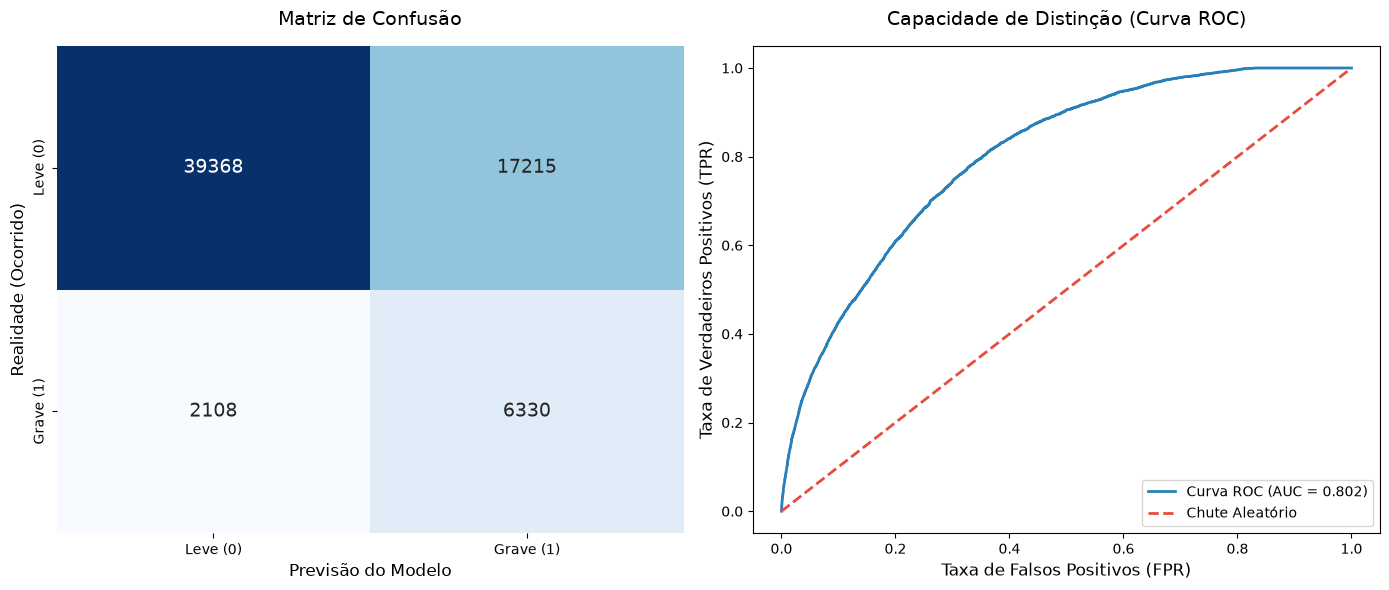

Acurácia: 0.7028 | Precision: 0.2688 | Recall: 0.7502 | AUC: 0.8020


In [ ]:
from sklearn.metrics import precision_recall_curve

RECALL_ALVO = 0.75

y_prob = modelo.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

candidatos = recalls[:-1] >= RECALL_ALVO
if candidatos.any():
    LIMIAR_DECISAO = thresholds[candidatos][np.argmax(precisions[:-1][candidatos])]
else:
    LIMIAR_DECISAO = thresholds[np.argmax(recalls[:-1])]

y_pred = (y_prob >= LIMIAR_DECISAO).astype(int)
print(f"Limiar de decisão calibrado para recall >= {RECALL_ALVO:.0%}: {LIMIAR_DECISAO:.4f}")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("--- RELATÓRIO DE CLASSIFICAÇÃO: Regressão Logística ---")
print(classification_report(y_test, y_pred, target_names=['0: Leve/Sem Vítimas', '1: Grave/Fatal']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Leve (0)', 'Grave (1)'],
            yticklabels=['Leve (0)', 'Grave (1)'],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15)
axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
axes[0].set_ylabel('Realidade (Ocorrido)', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Chute Aleatório')
axes[1].set_title('Capacidade de Distinção (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Acurácia: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | AUC: {auc:.4f}")


## 5. Interpretação do Modelo: Peso das Variáveis (Odds Ratio)

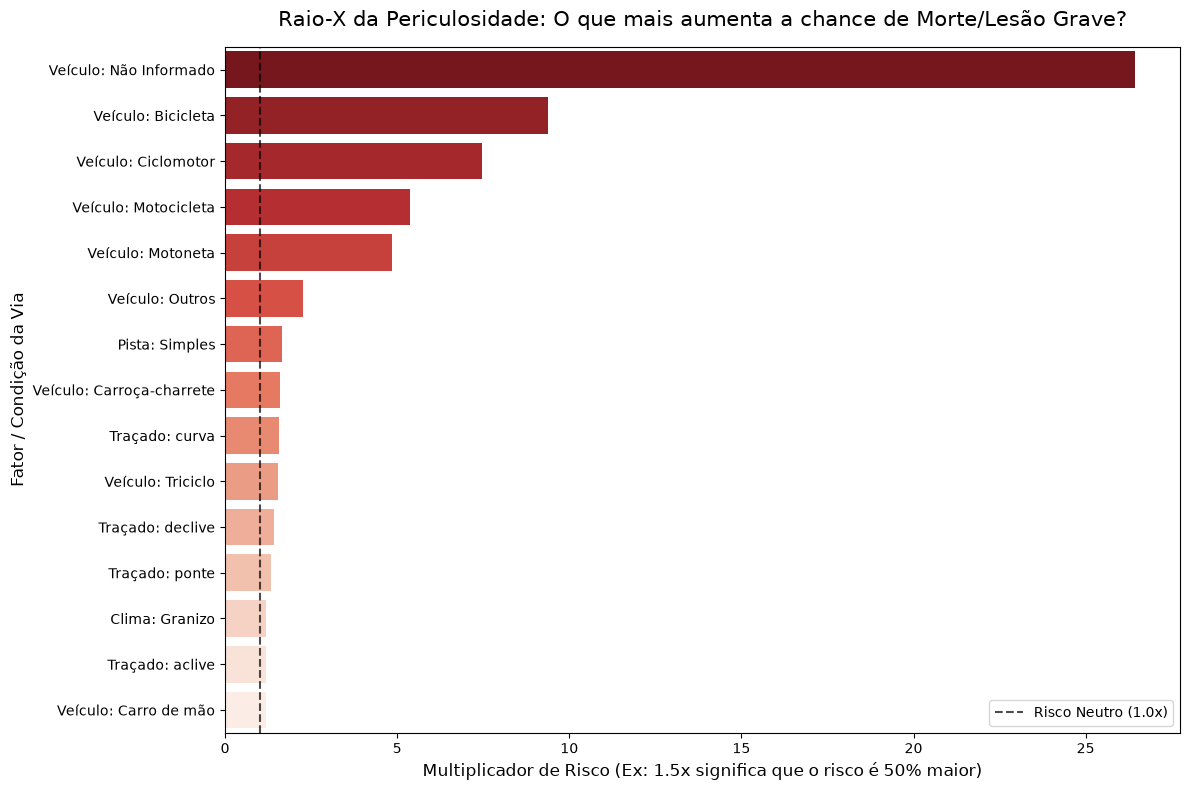

--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE ---
           Variavel_Limpa  Multiplicador_Risco
   Veículo: Não Informado            26.420870
       Veículo: Bicicleta             9.392486
      Veículo: Ciclomotor             7.464824
     Veículo: Motocicleta             5.370123
        Veículo: Motoneta             4.854597
          Veículo: Outros             2.269182
           Pista: Simples             1.657626
Veículo: Carroça-charrete             1.608755
           Traçado: curva             1.564317
        Veículo: Triciclo             1.529826


In [ ]:
coeficientes = modelo.coef_[0]
odds_ratios = np.exp(coeficientes)

df_importancia = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': coeficientes,
    'Multiplicador_Risco': odds_ratios
})

substituicoes_prefixos = {
    'tipo_veiculo_': 'Veículo: ',
    'tracado_': 'Traçado: ',
    'condicao_metereologica_': 'Clima: ',
    'fase_dia_': 'Luz: ',
    'turno_': 'Turno: ',
    'tipo_pista_': 'Pista: ',
    'sentido_via_': 'Sentido: ',
    'uso_solo_': 'Local: '
}

df_importancia['Variavel_Limpa'] = df_importancia['Variavel']
for prefixo, novo_nome in substituicoes_prefixos.items():
    df_importancia['Variavel_Limpa'] = df_importancia['Variavel_Limpa'].str.replace(prefixo, novo_nome)

df_importancia = df_importancia.sort_values(by='Multiplicador_Risco', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_importancia.head(15), x='Multiplicador_Risco', y='Variavel_Limpa', palette='Reds_r')
plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Risco Neutro (1.0x)')
plt.title('Raio-X da Periculosidade: O que mais aumenta a chance de Morte/Lesão Grave?', fontsize=15, pad=15)
plt.xlabel('Multiplicador de Risco (Ex: 1.5x significa que o risco é 50% maior)', fontsize=12)
plt.ylabel('Fator / Condição da Via', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE ---")
print(df_importancia.head(10)[['Variavel_Limpa', 'Multiplicador_Risco']].to_string(index=False))


## 5.1. Por que "Não Informado" aparece entre as variáveis mais relevantes?

`sexo_Não Informado` e `tipo_veiculo_Não Informado` aparecem entre as variáveis mais relevantes do modelo. Diferente das versões anteriores, não filtramos mais essas categorias do gráfico de odds ratio - investigamos a que esse sinal se refere em vez de escondê-lo.

In [ ]:
# Diagnóstico: por que sexo_Não Informado e tipo_veiculo_Não Informado pesam tanto?
taxa_geral = y_train.mean() * 100
print(f"Taxa geral de severidade (treino): {taxa_geral:.2f}%\n")

for col in ['sexo_Não Informado', 'tipo_veiculo_Não Informado']:
    if col in X_train.columns:
        mask = X_train[col] == 1
        taxa_sub = y_train[mask].mean() * 100
        print(f"{col}: {mask.sum()} registros ({mask.mean()*100:.1f}% da base de treino) "
              f"| taxa de severidade = {taxa_sub:.2f}%")

# Hipótese: sexo Não Informado se concentra em veículos sem condutor próprio (reboques/semirreboques)
if 'sexo_Não Informado' in X_train.columns:
    cols_veiculo = [c for c in X_train.columns if c.startswith('tipo_veiculo_')]
    print("\nTipos de veículo mais frequentes quando sexo = Não Informado:")
    print(X_train.loc[X_train['sexo_Não Informado'] == 1, cols_veiculo].sum().sort_values(ascending=False).head(5))

print(
    "\nInterpretação: 'sexo_Não Informado' concentra-se em registros de reboque/semirreboque "
    "(veículo sem condutor próprio) - por isso a taxa de severidade nesse grupo tende a zero: "
    "não é que 'sexo desconhecido' proteja contra acidente grave, é que esse registro descreve "
    "o veículo, não uma pessoa ferida (artefato da granularidade por pessoa/veículo-envolvido "
    "do dataset). Já 'tipo_veiculo_Não Informado' tem taxa de severidade ACIMA da média - "
    "plausivelmente porque acidentes mais graves (destruição do veículo, fuga, múltiplos "
    "envolvidos) dificultam o preenchimento correto do formulário PRF. Mantemos essas colunas "
    "no modelo (não removemos as linhas), mas é importante que o time saiba que parte dessa "
    "importância reflete o PROCESSO de registro do acidente, não um fator de risco da via em si."
)

Taxa geral de severidade (treino): 12.98%

sexo_Não Informado: 22094 registros (14.6% da base de treino) | taxa de severidade = 0.00%
tipo_veiculo_Não Informado: 4994 registros (3.3% da base de treino) | taxa de severidade = 35.42%

Tipos de veículo mais frequentes quando sexo = Não Informado:
tipo_veiculo_Semireboque      11529
tipo_veiculo_Não Informado     2248
tipo_veiculo_Reboque           1092
tipo_veiculo_Caminhão          1019
tipo_veiculo_Motocicleta        942
dtype: int64

Interpretação: 'sexo_Não Informado' concentra-se em registros de reboque/semirreboque (veículo sem condutor próprio) - por isso a taxa de severidade nesse grupo tende a zero: não é que 'sexo desconhecido' proteja contra acidente grave, é que esse registro descreve o veículo, não uma pessoa ferida (artefato da granularidade por pessoa/veículo-envolvido do dataset). Já 'tipo_veiculo_Não Informado' tem taxa de severidade ACIMA da média - plausivelmente porque acidentes mais graves (destruição do veículo, fuga

## 6. Exportação do Modelo e das Métricas

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(modelo, '../models/modelo_regressao_logistica.pkl')
joblib.dump(X_train.columns.tolist(), '../models/colunas_treino.pkl')

resultado = {
    'chave': 'regressao_logistica',
    'algoritmo': 'Regressão Logística (Baseline)',
    'acuracia': round(float(acc), 4),
    'precision': round(float(prec), 4),
    'recall': round(float(rec), 4),
    'auc_score': round(float(auc), 4),
    'tempo_segundos': round(float(tempo_treino), 4),
}

with open('../models/resultados_regressao_logistica.json', 'w', encoding='utf-8') as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)

print(f"✅ Modelo e métricas de Regressão Logística (Baseline) exportados com sucesso!")
resultado


✅ Modelo e métricas de Regressão Logística (Baseline) exportados com sucesso!


{'chave': 'regressao_logistica',
 'algoritmo': 'Regressão Logística (Baseline)',
 'acuracia': 0.7028,
 'precision': 0.2688,
 'recall': 0.7502,
 'auc_score': 0.802,
 'tempo_segundos': 1.7316}